# AI5707 — Pattern Recognition and Machine Learning
## Assignment 5: Maximum Likelihood Parameter Estimation

This notebook implements the Gaussian MLE classifier experiments and the real-data classification task. Run cells **from top to bottom**. The synthetic experiments use 10,000 observations per class before an 80/20 train/test split. The supplied `trian.txt` and `dev.txt` files are retained as the real-data training and held-out test sets, respectively.

# Mathematical Formulation — Maximum Likelihood Estimation

### Multivariate Gaussian probability density

$$
p(\mathbf{x}\mid\omega_i)
=
\frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}_i|^{1/2}}
\exp\left[
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
\right]
$$

### MLE of the mean

$$
\boxed{
\hat{\boldsymbol{\mu}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}\mathbf{x}_n
}
$$

### MLE of the covariance matrix

$$
\boxed{
\hat{\boldsymbol{\Sigma}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)^T
}
$$

### Covariance assumptions

**Isotropic:**

$$
\boxed{\boldsymbol{\Sigma}_i=\sigma_i^2\mathbf{I}}
$$

**Diagonal:**

$$
\boxed{
\boldsymbol{\Sigma}_i=
\operatorname{diag}
(\sigma_{i1}^{2},\sigma_{i2}^{2},\ldots,\sigma_{id}^{2})
}
$$

**Full covariance:**

$$
\boxed{
\boldsymbol{\Sigma}_i =
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots\\
\sigma_{21} & \sigma_{22} & \cdots\\
\vdots & \vdots & \ddots
\end{bmatrix}
}
$$

### Gaussian discriminant function

$$
\boxed{
g_i(\mathbf{x})
=
-\frac{1}{2}\ln|\boldsymbol{\Sigma}_i|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
+\ln P(\omega_i)
}
$$

Classification rule:

$$
\boxed{
\hat{y}
=
\arg\max_i g_i(\mathbf{x})
}
$$

### Decision boundary

Between classes $i$ and $j$:

$$
\boxed{g_i(\mathbf{x})=g_j(\mathbf{x})}
$$

If all classes share the same covariance,

$$
\boldsymbol{\Sigma}_1=\boldsymbol{\Sigma}_2=\boldsymbol{\Sigma}_3,
$$

the quadratic terms cancel and the boundary becomes linear.

### Confusion-matrix metrics

$$
\mathrm{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
\mathrm{TPR}
=
\frac{TP}{TP+FN}
\qquad
\mathrm{FPR}
=
\frac{FP}{FP+TN}
$$

### ROC and AUC

The ROC curve plots

$$
\boxed{\mathrm{TPR}\ \text{against}\ \mathrm{FPR}}
$$

as the decision threshold varies.

The area under the curve is

$$
\boxed{
\mathrm{AUC}
=
\int_0^1
\mathrm{TPR}(\mathrm{FPR})\,d(\mathrm{FPR})
}
$$


# Mathematical Formulation — Maximum Likelihood Estimation

## 1. Multivariate Gaussian model

For a $d$-dimensional observation $\mathbf{x}$ belonging to class $i$:

$$
p(\mathbf{x}\mid\omega_i)
=
\frac{1}
{(2\pi)^{d/2}\,|\boldsymbol{\Sigma}_i|^{1/2}}
\exp\left[
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
\right]
$$

where:

- $\boldsymbol{\mu}_i$ is the class mean vector.
- $\boldsymbol{\Sigma}_i$ is the class covariance matrix.
- $|\boldsymbol{\Sigma}_i|$ is the determinant.
- $d$ is the number of features.

## 2. Maximum likelihood estimate of the mean

For $N_i$ training samples in class $i$,

$$
\boxed{
\hat{\boldsymbol{\mu}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}\mathbf{x}_n
}
$$

The estimated mean is therefore the sample average of all training vectors belonging to the class.

## 3. Maximum likelihood estimate of covariance

The MLE covariance estimate is

$$
\boxed{
\hat{\boldsymbol{\Sigma}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)^T
}
$$

The denominator is $N_i$ because this is the **maximum likelihood estimator**, rather than the unbiased sample covariance estimator.

## 4. Three covariance models used in the assignment

### A. Isotropic covariance

$$
\boxed{
\boldsymbol{\Sigma}_i=\sigma_i^2\mathbf{I}
}
$$

All features have the same variance and the covariance between different features is zero.

### B. Diagonal covariance

$$
\boxed{
\boldsymbol{\Sigma}_i=
\begin{bmatrix}
\sigma_{i1}^{2} & 0 & \cdots & 0\\
0 & \sigma_{i2}^{2} & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \sigma_{id}^{2}
\end{bmatrix}
}
$$

Each feature can have a different variance, but all off-diagonal covariance terms are zero.

### C. Full covariance

$$
\boxed{
\boldsymbol{\Sigma}_i=
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots\\
\sigma_{21} & \sigma_{22} & \cdots\\
\vdots & \vdots & \ddots
\end{bmatrix}
}
$$

Here, both variances and cross-feature covariance terms are estimated.

## 5. Gaussian discriminant function

Assuming equal class priors, classification can be performed using the log-likelihood:

$$
g_i(\mathbf{x})
=
-\frac{1}{2}\ln|\boldsymbol{\Sigma}_i|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
$$

The predicted class is

$$
\boxed{
\hat{y}
=
\arg\max_i g_i(\mathbf{x})
}
$$

If class priors are included, the discriminant becomes

$$
g_i(\mathbf{x})
=
-\frac{1}{2}\ln|\boldsymbol{\Sigma}_i|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
+\ln P(\omega_i)
$$

## 6. Decision boundary

The boundary between classes $i$ and $j$ is obtained from

$$
\boxed{
g_i(\mathbf{x})=g_j(\mathbf{x})
}
$$

For full covariance matrices, this generally produces a **quadratic decision boundary**.

When the covariance matrix is shared by all classes,

$$
\boldsymbol{\Sigma}_1
=
\boldsymbol{\Sigma}_2
=
\boldsymbol{\Sigma}_3
=
\boldsymbol{\Sigma}
$$

the quadratic terms cancel, giving a **linear decision boundary**.

## 7. ROC curve

For a one-vs-rest class decision, the ROC curve plots

$$
\mathrm{TPR}
=
\frac{\mathrm{TP}}
{\mathrm{TP}+\mathrm{FN}}
$$

against

$$
\mathrm{FPR}
=
\frac{\mathrm{FP}}
{\mathrm{FP}+\mathrm{TN}}
$$

at different classification thresholds.

The area under the ROC curve is

$$
\boxed{
\mathrm{AUC}
=
\int_0^1 \mathrm{TPR}(\mathrm{FPR})\,d(\mathrm{FPR})
}
$$

An AUC close to $1$ indicates strong class discrimination, while an AUC close to $0.5$ corresponds approximately to random discrimination.


## 2. Imports and reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.figsize": (8, 6), "axes.grid": True, "grid.alpha": 0.25})
np.set_printoptions(precision=4, suppress=True)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.1.4


## 3. Gaussian MLE and prediction utilities

In [2]:
def _regularize_covariance(cov, eps=1e-6):
    """Symmetrize covariance and add a small diagonal term for numerical stability."""
    cov = np.asarray(cov, dtype=float)
    cov = (cov + cov.T) / 2.0
    return cov + eps * np.eye(cov.shape[0])


def _apply_covariance_structure(cov, covariance_type):
    """Project a covariance matrix onto spherical, diagonal, or full structure."""
    d = cov.shape[0]
    if covariance_type == "spherical":
        variance = np.trace(cov) / d
        cov = variance * np.eye(d)
    elif covariance_type == "diagonal":
        cov = np.diag(np.diag(cov))
    elif covariance_type == "full":
        cov = cov.copy()
    else:
        raise ValueError("covariance_type must be 'spherical', 'diagonal', or 'full'")
    return _regularize_covariance(cov)


def fit_gaussian_model(X, y, covariance_type="full", covariance_mode="different"):
    """Fit class means/priors and covariance(s) using training data only.

    covariance_mode='common' estimates one pooled within-class covariance;
    covariance_mode='different' estimates a separate covariance for each class.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes = np.unique(y)
    n, d = X.shape
    means, priors, raw_covs = {}, {}, {}

    for cls in classes:
        Xc = X[y == cls]
        means[cls] = Xc.mean(axis=0)
        priors[cls] = len(Xc) / n
        centered = Xc - means[cls]
        raw_covs[cls] = (centered.T @ centered) / len(Xc)  # MLE denominator N_k

    if covariance_mode == "common":
        pooled = np.zeros((d, d), dtype=float)
        for cls in classes:
            centered = X[y == cls] - means[cls]
            pooled += centered.T @ centered
        pooled /= n  # pooled MLE covariance, weighted by class sample count
        common_cov = _apply_covariance_structure(pooled, covariance_type)
        covariances = {cls: common_cov.copy() for cls in classes}
    elif covariance_mode == "different":
        covariances = {
            cls: _apply_covariance_structure(raw_covs[cls], covariance_type)
            for cls in classes
        }
    else:
        raise ValueError("covariance_mode must be 'common' or 'different'")

    return {"classes": classes, "means": means, "covariances": covariances,
            "priors": priors, "covariance_type": covariance_type,
            "covariance_mode": covariance_mode}


def gaussian_scores(X, model):
    """Return one Gaussian log-discriminant score column per class."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    classes = model["classes"]
    scores = np.empty((X.shape[0], len(classes)), dtype=float)
    d = X.shape[1]
    for j, cls in enumerate(classes):
        mean = model["means"][cls]
        cov = _regularize_covariance(model["covariances"][cls])
        sign, logdet = np.linalg.slogdet(cov)
        if sign <= 0:
            raise np.linalg.LinAlgError(f"Covariance for class {cls} is not positive definite")
        diff = X - mean
        solved = np.linalg.solve(cov, diff.T).T
        mahalanobis = np.einsum("ij,ij->i", diff, solved)
        scores[:, j] = (-0.5 * d * np.log(2 * np.pi) - 0.5 * logdet
                        - 0.5 * mahalanobis + np.log(model["priors"][cls]))
    return scores


def gaussian_predict(X, model):
    return model["classes"][np.argmax(gaussian_scores(X, model), axis=1)]


def show_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    display(pd.DataFrame(cm, index=[f"Actual {c}" for c in classes],
                         columns=[f"Predicted {c}" for c in classes]).style.set_caption(title))
    return cm

## 4. Synthetic dataset generation

In [3]:
N_PER_CLASS = 10_000
CLASS_MEANS = {
    1: np.array([2.0, 2.0]),
    2: np.array([7.0, 3.5]),
    3: np.array([4.0, 8.0]),
}

# Distinct positive-definite covariance matrices for the different-covariance case.
COVS_FULL_DIFFERENT = {
    1: np.array([[1.00, 0.25], [0.25, 1.40]]),
    2: np.array([[1.60, -0.45], [-0.45, 0.80]]),
    3: np.array([[0.90, 0.35], [0.35, 1.80]]),
}
COVS_DIAGONAL_DIFFERENT = {
    1: np.diag([0.8, 1.2]),
    2: np.diag([1.5, 0.7]),
    3: np.diag([0.9, 1.8]),
}
COVS_SPHERICAL_DIFFERENT = {
    1: 0.8 * np.eye(2),
    2: 1.4 * np.eye(2),
    3: 1.0 * np.eye(2),
}

COMMON_COVS = {
    "spherical": 1.0 * np.eye(2),
    "diagonal": np.diag([1.0, 1.5]),
    "full": np.array([[1.2, 0.35], [0.35, 1.4]]),
}
DIFFERENT_COVS = {
    "spherical": COVS_SPHERICAL_DIFFERENT,
    "diagonal": COVS_DIAGONAL_DIFFERENT,
    "full": COVS_FULL_DIFFERENT,
}

synthetic_datasets = {}
experiments = [
    ("Spherical - Common", "spherical", "common"),
    ("Diagonal - Common", "diagonal", "common"),
    ("Full - Common", "full", "common"),
    ("Spherical - Different", "spherical", "different"),
    ("Diagonal - Different", "diagonal", "different"),
    ("Full - Different", "full", "different"),
]

for name, cov_type, cov_mode in experiments:
    chunks, labels = [], []
    for cls, mean in CLASS_MEANS.items():
        cov = COMMON_COVS[cov_type] if cov_mode == "common" else DIFFERENT_COVS[cov_type][cls]
        samples = rng.multivariate_normal(mean, cov, size=N_PER_CLASS)
        chunks.append(samples)
        labels.append(np.full(N_PER_CLASS, cls, dtype=int))
    X = np.vstack(chunks)
    y = np.concatenate(labels)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=SEED, stratify=y
    )
    synthetic_datasets[name] = {
        "X": X, "y": y, "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "covariance_type": cov_type, "covariance_mode": cov_mode,
    }

print(f"Created {len(synthetic_datasets)} synthetic datasets.")
for name, data in synthetic_datasets.items():
    print(f"{name:24s}: train={data['X_train'].shape}, test={data['X_test'].shape}")

Created 6 synthetic datasets.
Spherical - Common      : train=(24000, 2), test=(6000, 2)
Diagonal - Common       : train=(24000, 2), test=(6000, 2)
Full - Common           : train=(24000, 2), test=(6000, 2)
Spherical - Different   : train=(24000, 2), test=(6000, 2)
Diagonal - Different    : train=(24000, 2), test=(6000, 2)
Full - Different        : train=(24000, 2), test=(6000, 2)


## 5. Fit and evaluate all six synthetic experiments

In [4]:
synthetic_results = {}
summary_rows = []
classes_synthetic = np.array(sorted(CLASS_MEANS))

for name, data in synthetic_datasets.items():
    model = fit_gaussian_model(
        data["X_train"], data["y_train"],
        covariance_type=data["covariance_type"],
        covariance_mode=data["covariance_mode"]
    )
    y_pred = gaussian_predict(data["X_test"], model)
    cm = confusion_matrix(data["y_test"], y_pred, labels=classes_synthetic)
    acc = accuracy_score(data["y_test"], y_pred)
    synthetic_results[name] = {
        **model,
        "X_test": data["X_test"], "y_test": data["y_test"],
        "y_pred": y_pred, "confusion_matrix": cm, "accuracy": acc,
    }
    summary_rows.append({"Experiment": name,
                         "Covariance type": data["covariance_type"],
                         "Covariance mode": data["covariance_mode"],
                         "Test samples": len(data["y_test"]),
                         "Accuracy": acc})

synthetic_summary = pd.DataFrame(summary_rows).sort_values("Experiment").reset_index(drop=True)
display(synthetic_summary.style.format({"Accuracy": "{:.4f}"}).set_caption("Synthetic test-set performance"))

,Experiment,Covariance type,Covariance mode,Test samples,Accuracy
0,Diagonal - Common,diagonal,common,6000,0.9880
1,Diagonal - Different,diagonal,different,6000,0.9887
2,Full - Common,full,common,6000,0.9877
3,Full - Different,full,different,6000,0.9852
4,Spherical - Common,spherical,common,6000,0.9952
5,Spherical - Different,spherical,different,6000,0.9903


### 5.1 Confusion matrices

In [5]:
for name, result in synthetic_results.items():
    show_confusion_matrix(result["y_test"], result["y_pred"], classes_synthetic,
                          f"Confusion matrix — {name}")

,Predicted 1,Predicted 2,Predicted 3
Actual 1,1996,4,0
Actual 2,6,1986,8
Actual 3,2,9,1989


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1981,15,4
Actual 2,8,1969,23
Actual 3,5,17,1978


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1968,17,15
Actual 2,25,1972,3
Actual 3,10,4,1986


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1985,14,1
Actual 2,18,1966,16
Actual 3,0,9,1991


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1979,14,7
Actual 2,12,1980,8
Actual 3,8,19,1973


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1974,15,11
Actual 2,11,1970,19
Actual 3,16,17,1967


### 5.2 Estimated parameters

In [6]:
for name, result in synthetic_results.items():
    print("\n" + "=" * 72 + f"\n{name}")
    for cls in result["classes"]:
        print(f"Class {cls}: prior={result['priors'][cls]:.4f}")
        print(f"  mean = {result['means'][cls]}")
        print(f"  covariance =\n{result['covariances'][cls]}")


Spherical - Common
Class 1: prior=0.3333
  mean = [1.992  2.0103]
  covariance =
[[1.0074 0.    ]
 [0.     1.0074]]
Class 2: prior=0.3333
  mean = [7.0016 3.5119]
  covariance =
[[1.0074 0.    ]
 [0.     1.0074]]
Class 3: prior=0.3333
  mean = [3.9916 7.9816]
  covariance =
[[1.0074 0.    ]
 [0.     1.0074]]

Diagonal - Common
Class 1: prior=0.3333
  mean = [2.0048 1.9864]
  covariance =
[[1.0052 0.    ]
 [0.     1.4998]]
Class 2: prior=0.3333
  mean = [6.9926 3.4924]
  covariance =
[[1.0052 0.    ]
 [0.     1.4998]]
Class 3: prior=0.3333
  mean = [3.9912 7.9982]
  covariance =
[[1.0052 0.    ]
 [0.     1.4998]]

Full - Common
Class 1: prior=0.3333
  mean = [2.0044 1.9786]
  covariance =
[[1.1968 0.3351]
 [0.3351 1.4028]]
Class 2: prior=0.3333
  mean = [7.0055 3.487 ]
  covariance =
[[1.1968 0.3351]
 [0.3351 1.4028]]
Class 3: prior=0.3333
  mean = [3.9674 7.9957]
  covariance =
[[1.1968 0.3351]
 [0.3351 1.4028]]

Spherical - Different
Class 1: prior=0.3333
  mean = [1.9779 2.0102]
  c

## 6. Synthetic decision boundaries

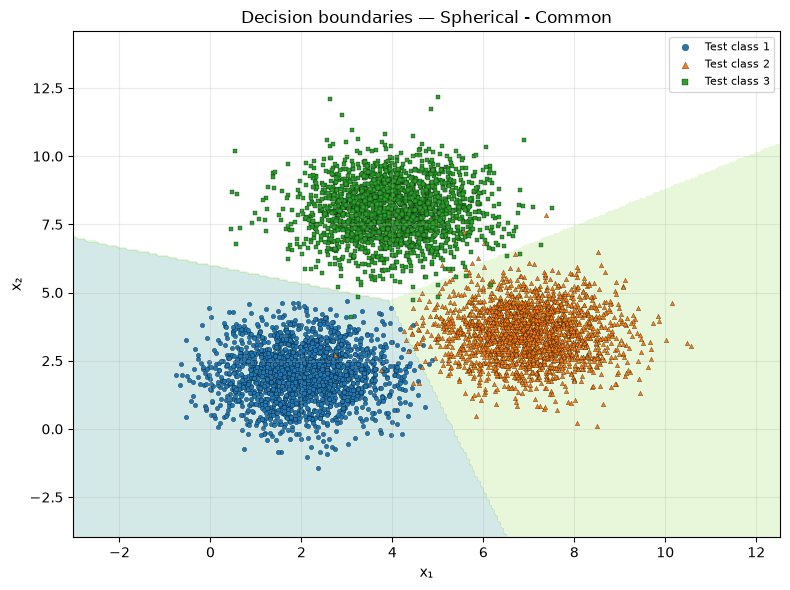

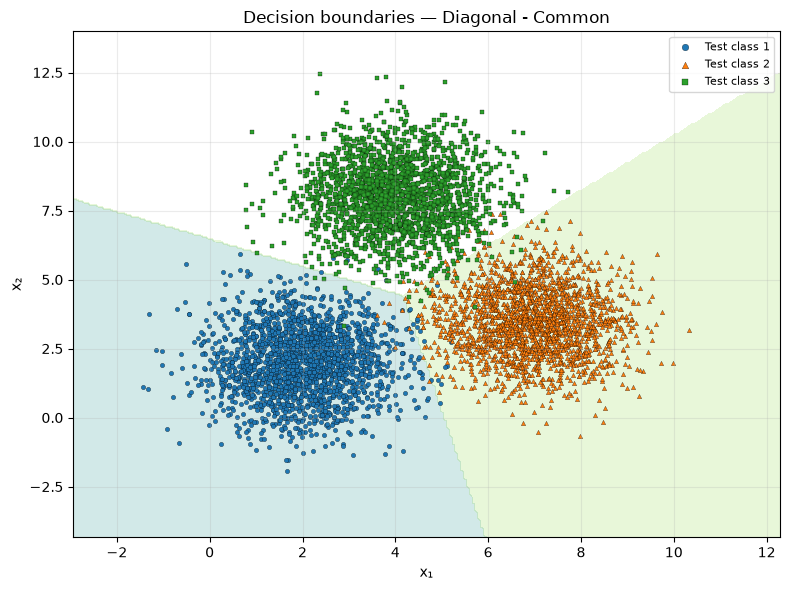

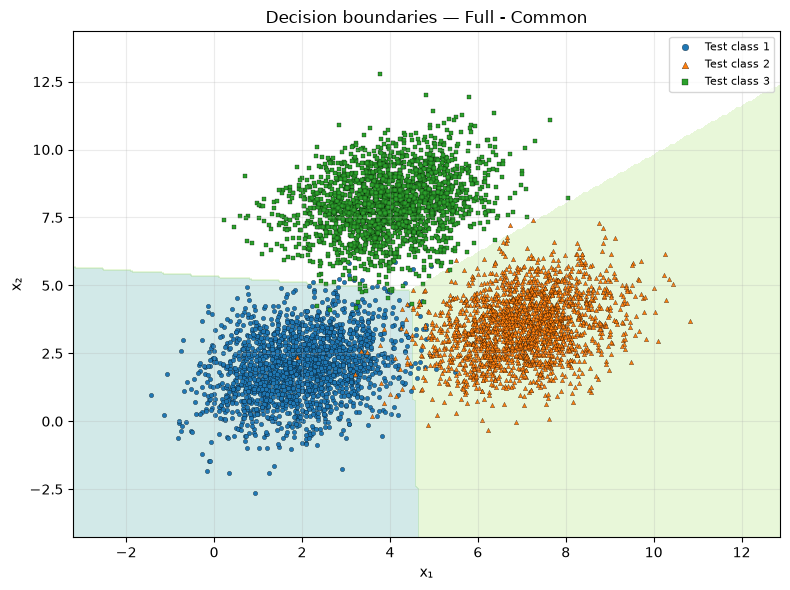

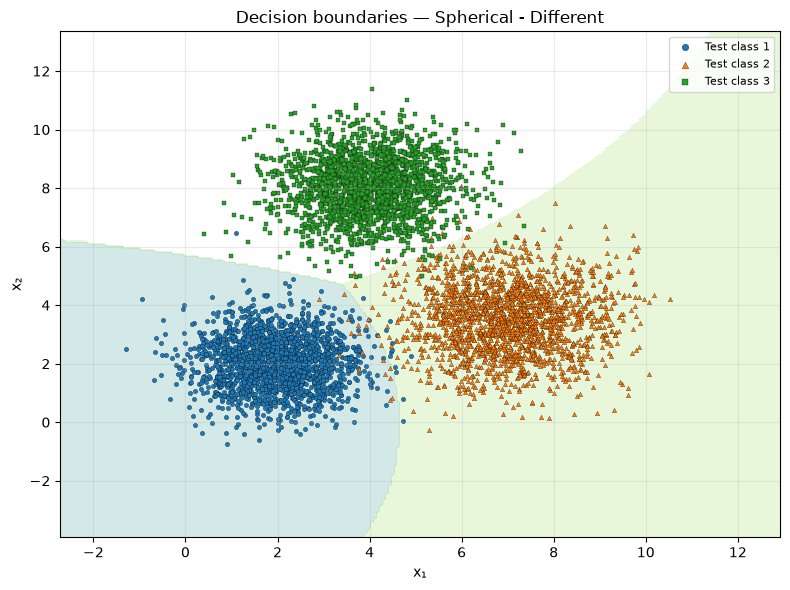

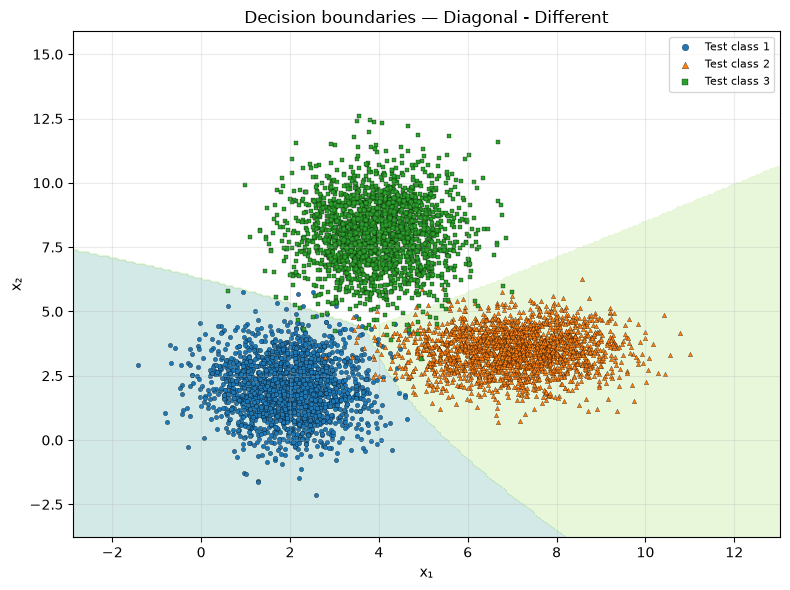

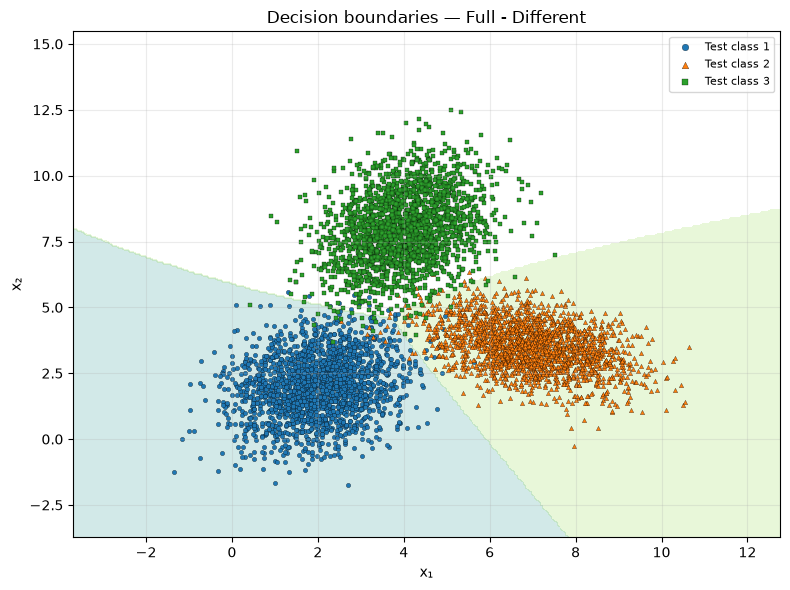

In [7]:
def plot_decision_boundary(X_train, X_test, y_test, model, title, resolution=250):
    X_all = np.vstack([X_train, X_test])
    pad_x = 0.8 + 0.05 * np.ptp(X_all[:, 0])
    pad_y = 0.8 + 0.05 * np.ptp(X_all[:, 1])
    x_min, x_max = X_all[:, 0].min() - pad_x, X_all[:, 0].max() + pad_x
    y_min, y_max = X_all[:, 1].min() - pad_y, X_all[:, 1].max() + pad_y
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    Z = gaussian_predict(grid, model).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.20, levels=np.arange(len(model["classes"]) + 1) - 0.5,
                 cmap="viridis")
    for cls, marker in zip(model["classes"], ["o", "^", "s", "D"]):
        mask = np.asarray(y_test) == cls
        plt.scatter(X_test[mask, 0], X_test[mask, 1], s=10, marker=marker,
                    edgecolors="black", linewidths=0.2, label=f"Test class {cls}")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title(title)
    plt.legend(markerscale=1.5, fontsize=8)
    plt.tight_layout()
    plt.show()

for name, result in synthetic_results.items():
    data = synthetic_datasets[name]
    plot_decision_boundary(data["X_train"], result["X_test"], result["y_test"],
                           result, f"Decision boundaries — {name}")

## 7. ROC curves and AUC — synthetic experiments

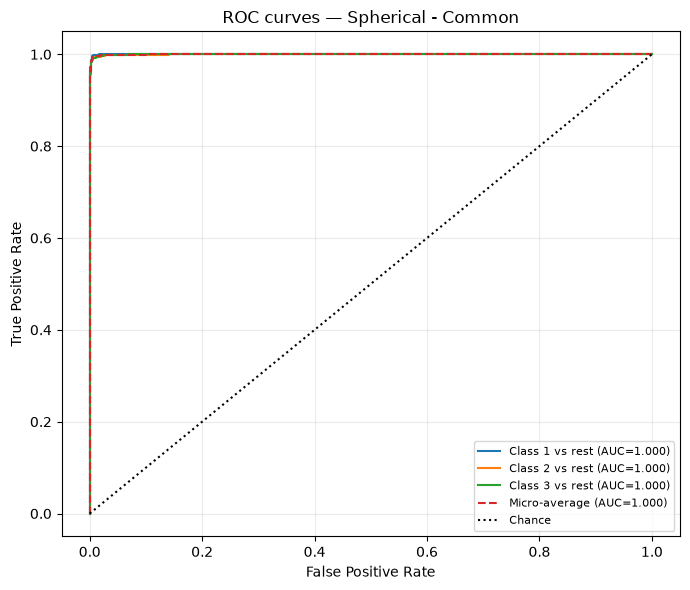

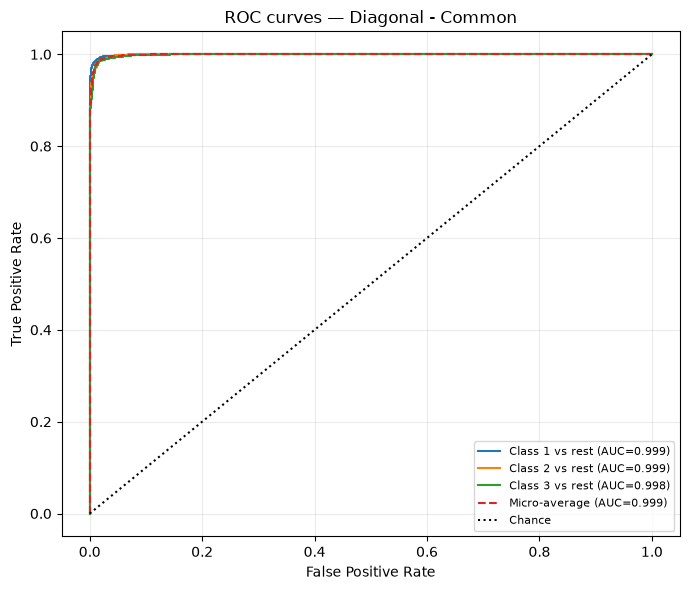

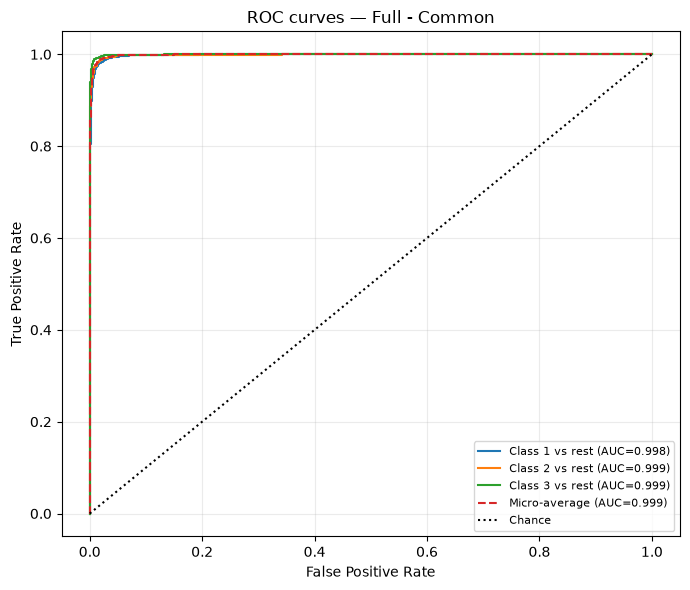

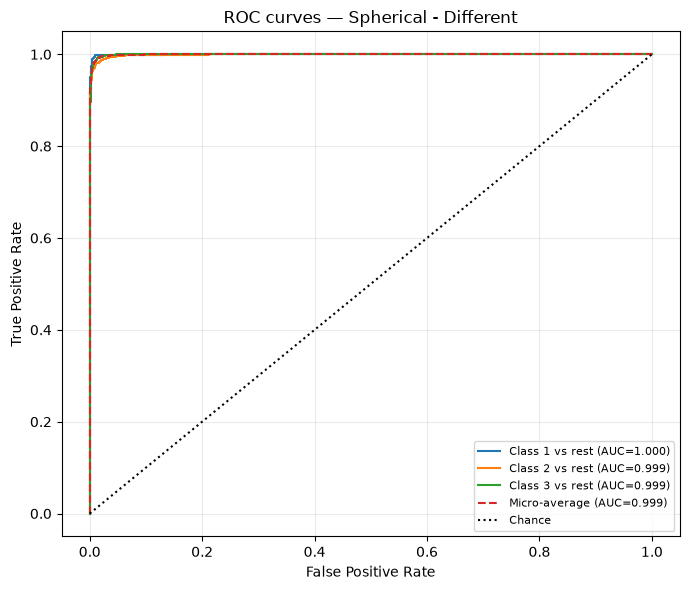

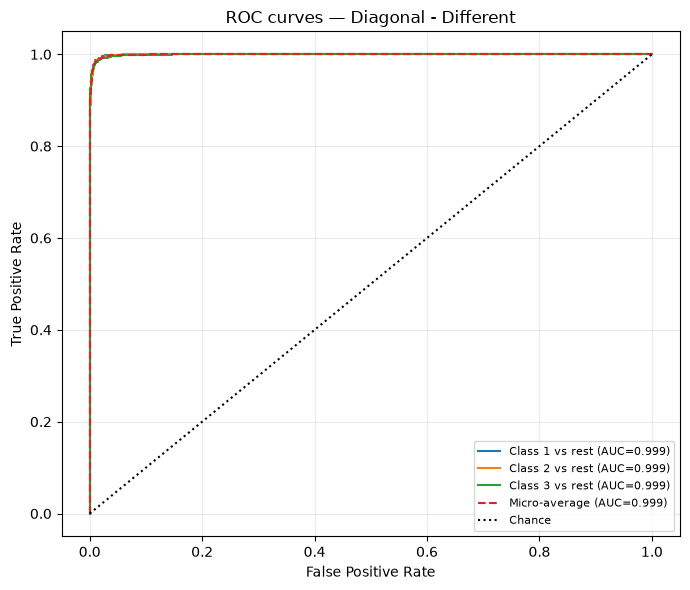

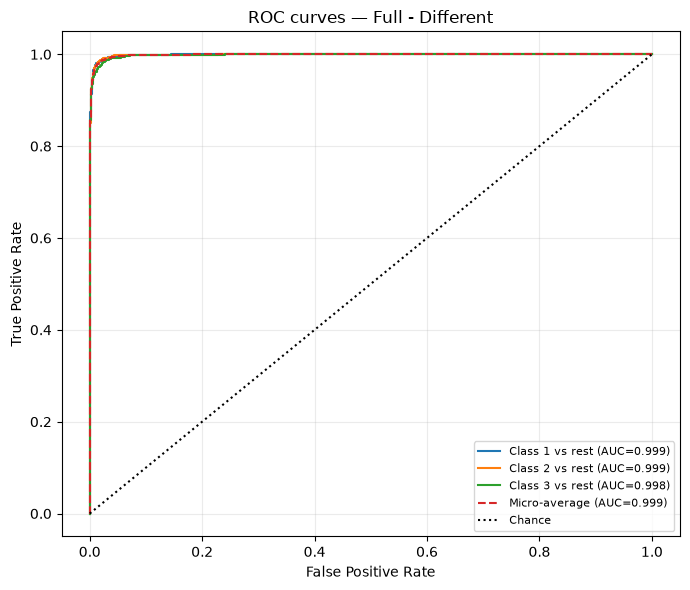

,Experiment,Micro-average AUC,Class 1 AUC,Class 2 AUC,Class 3 AUC
0,Spherical - Common,0.9996,0.9997,0.9995,0.9997
1,Diagonal - Common,0.9989,0.9994,0.9988,0.9985
2,Full - Common,0.9987,0.9980,0.9988,0.9994
3,Spherical - Different,0.9993,0.9996,0.9989,0.9993
4,Diagonal - Different,0.9992,0.9993,0.9992,0.9991
5,Full - Different,0.9986,0.9988,0.9987,0.9982


In [8]:
def plot_multiclass_roc(X_test, y_test, model, title):
    """Plot one-vs-rest ROC curves using each class's Gaussian discriminant score."""
    classes = model["classes"]
    y_bin = label_binarize(y_test, classes=classes)
    scores = gaussian_scores(X_test, model)
    fpr, tpr, aucs = {}, {}, {}
    for j, cls in enumerate(classes):
        fpr[cls], tpr[cls], _ = roc_curve(y_bin[:, j], scores[:, j])
        aucs[cls] = auc(fpr[cls], tpr[cls])
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), scores.ravel())
    aucs["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(7, 6))
    for cls in classes:
        plt.plot(fpr[cls], tpr[cls], label=f"Class {cls} vs rest (AUC={aucs[cls]:.3f})")
    plt.plot(fpr["micro"], tpr["micro"], linestyle="--",
             label=f"Micro-average (AUC={aucs['micro']:.3f})")
    plt.plot([0, 1], [0, 1], "k:", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
    return aucs

synthetic_auc = {}
for name, result in synthetic_results.items():
    synthetic_auc[name] = plot_multiclass_roc(
        result["X_test"], result["y_test"], result, f"ROC curves — {name}"
    )

auc_rows = []
for name, values in synthetic_auc.items():
    row = {"Experiment": name, "Micro-average AUC": values["micro"]}
    for cls in classes_synthetic:
        row[f"Class {cls} AUC"] = values[cls]
    auc_rows.append(row)
synthetic_auc_summary = pd.DataFrame(auc_rows)
display(synthetic_auc_summary.style.format({c: "{:.4f}" for c in synthetic_auc_summary.columns if c != "Experiment"}))

## 8. Real 2-D dataset

The provided files are used as intended: `trian.txt` is the labeled training set and `dev.txt` is the held-out test set. This preserves the supplied split rather than mixing the two files and accidentally leaking test observations into training. The split in these supplied files is 1,050 training observations and 300 development/test observations; it is not exactly 80/20 of their combined total. If your instructor explicitly requires a fresh 80/20 split of the combined rows, that would be a different protocol.

In [9]:

from pathlib import Path
import pandas as pd
import numpy as np

def find_data_file(candidates):
    """Find a data file in common notebook directories."""
    search_roots = [
        Path.cwd(),
        Path("/content"),
        Path("/mnt/data")
    ]

    for root in search_roots:
        for name in candidates:
            candidate = root / name

            if candidate.is_file():
                return candidate

    raise FileNotFoundError(
        f"Could not find any of {candidates}. "
        "Check the uploaded files and their paths."
    )


# Check both possible spellings of the training filename
TRAIN_FILE = find_data_file(["train.txt", "trian.txt"])
DEV_FILE = find_data_file(["dev.txt"])


def load_xy_label(path):
    df = pd.read_csv(path, header=None, sep=None, engine="python")

    if df.shape[1] != 3:
        raise ValueError(
            f"Expected 3 columns (x, y, class) in {path}; "
            f"got {df.shape[1]}"
        )

    df.columns = ["x", "y", "class"]
    df = df.apply(pd.to_numeric, errors="raise")

    if df.isna().any().any():
        raise ValueError(f"Missing values found in {path}")

    df["class"] = df["class"].astype(int)
    return df


real_train_df = load_xy_label(TRAIN_FILE)
real_test_df = load_xy_label(DEV_FILE)

X_train_real = real_train_df[["x", "y"]].to_numpy(dtype=float)
y_train_real = real_train_df["class"].to_numpy(dtype=int)

X_test_real = real_test_df[["x", "y"]].to_numpy(dtype=float)
y_test_real = real_test_df["class"].to_numpy(dtype=int)

real_classes = np.unique(
    np.concatenate([y_train_real, y_test_real])
)

print("Training file:", TRAIN_FILE, "shape:", real_train_df.shape)
print("Development file:", DEV_FILE, "shape:", real_test_df.shape)

print("Training class counts:\n",
      real_train_df["class"].value_counts().sort_index())

print("Test class counts:\n",
      real_test_df["class"].value_counts().sort_index())


Training file: d:\Storage\OneDrive\Documents\SNU Chennai\PRML Lab\Lab 5\train.txt shape: (1050, 3)
Development file: d:\Storage\OneDrive\Documents\SNU Chennai\PRML Lab\Lab 5\dev.txt shape: (300, 3)
Training class counts:
 class
1    350
2    350
3    350
Name: count, dtype: int64
Test class counts:
 class
1    100
2    100
3    100
Name: count, dtype: int64


### 8.1 Visualize the supplied real-data split

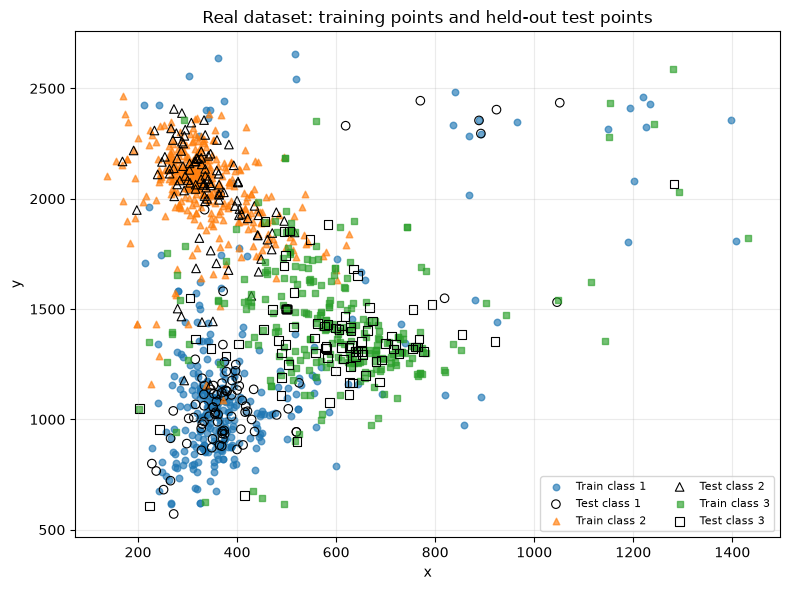

In [10]:
plt.figure(figsize=(8, 6))
markers = ["o", "^", "s", "D"]
for cls, marker in zip(real_classes, markers):
    train_mask = y_train_real == cls
    test_mask = y_test_real == cls
    plt.scatter(X_train_real[train_mask, 0], X_train_real[train_mask, 1],
                s=22, marker=marker, alpha=0.65, label=f"Train class {cls}")
    plt.scatter(X_test_real[test_mask, 0], X_test_real[test_mask, 1],
                s=38, marker=marker, facecolors="none", edgecolors="black",
                linewidths=0.8, label=f"Test class {cls}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Real dataset: training points and held-out test points")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### 8.2 Fit full-covariance MLE and evaluate the held-out set

In [11]:
real_model = fit_gaussian_model(X_train_real, y_train_real,
                                covariance_type="full", covariance_mode="different")
y_pred_real = gaussian_predict(X_test_real, real_model)
real_accuracy = accuracy_score(y_test_real, y_pred_real)
real_cm = show_confusion_matrix(y_test_real, y_pred_real, real_classes,
                                "Real-data confusion matrix — full covariance")
print(f"Real-data test accuracy: {real_accuracy:.4f} ({real_accuracy:.2%})")

for cls in real_model["classes"]:
    print(f"\nClass {cls}: prior={real_model['priors'][cls]:.4f}")
    print("Mean:", real_model["means"][cls])
    print("Covariance:\n", real_model["covariances"][cls])

,Predicted 1,Predicted 2,Predicted 3
Actual 1,78,2,20
Actual 2,6,91,3
Actual 3,13,3,84


Real-data test accuracy: 0.8433 (84.33%)

Class 1: prior=0.3333
Mean: [ 432.094  1241.3891]
Covariance:
 [[ 33801.0721  39788.6866]
 [ 39788.6866 177814.494 ]]

Class 2: prior=0.3333
Mean: [ 336.6605 2037.8283]
Covariance:
 [[ 6783.4304 -5830.3857]
 [-5830.3857 39443.0699]]

Class 3: prior=0.3333
Mean: [ 575.9242 1456.2468]
Covariance:
 [[23925.5008  3605.1894]
 [ 3605.1894 59757.2704]]


### 8.3 Real-data decision boundary

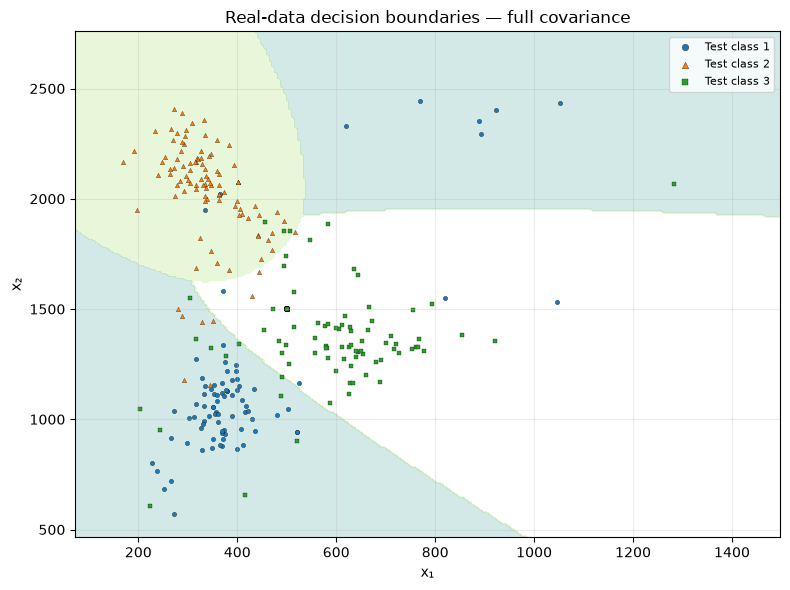

In [12]:
plot_decision_boundary(X_train_real, X_test_real, y_test_real, real_model,
                       "Real-data decision boundaries — full covariance")

### 8.4 Real-data ROC curves and AUC

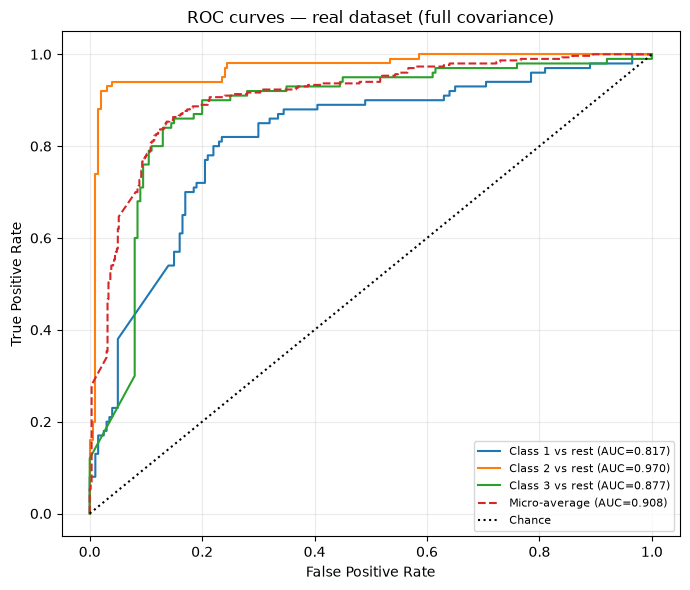

Real-data AUC values: {1: 0.8168, 2: 0.97, 3: 0.8775, 'micro': 0.9076}


In [13]:
real_auc = plot_multiclass_roc(X_test_real, y_test_real, real_model,
                               "ROC curves — real dataset (full covariance)")
print("Real-data AUC values:", {k: round(v, 4) for k, v in real_auc.items()})

## 9. Observations and discussion

Use the printed accuracy, confusion matrices, ROC plots, and AUC table above to write observations grounded in your run. Points to consider:

1. **Covariance assumption:** spherical covariance is restrictive; diagonal covariance models different variances but ignores feature correlation; full covariance can represent correlation but estimates more parameters.
2. **Common vs class-specific covariance:** a common covariance shares shape across classes, whereas class-specific covariance allows each class to have a different spread/orientation.
3. **Confusion matrix:** the diagonal entries are correct predictions; off-diagonal entries show which classes are confused.
4. **ROC/AUC:** one-vs-rest curves compare each class against the others. AUC closer to 1 indicates stronger ranking separation on the evaluated test set.
5. **Real data:** the real-data result is evaluated on the supplied held-out `dev` file. The synthetic and real-data accuracies should not be compared without noting their different data distributions and split sizes.

Do not state that one model is best unless the output tables/plots support that conclusion.

## 10. Final results table

In [14]:
final_rows = []
for name, result in synthetic_results.items():
    final_rows.append({"Dataset": name, "Accuracy": result["accuracy"],
                       "Micro AUC": synthetic_auc[name]["micro"]})
final_rows.append({"Dataset": "Real data — full covariance",
                   "Accuracy": real_accuracy, "Micro AUC": real_auc["micro"]})
final_results = pd.DataFrame(final_rows)
display(final_results.style.format({"Accuracy": "{:.4f}", "Micro AUC": "{:.4f}"})
        .set_caption("Summary of held-out test results"))

,Dataset,Accuracy,Micro AUC
0,Spherical - Common,0.9952,0.9996
1,Diagonal - Common,0.9880,0.9989
2,Full - Common,0.9877,0.9987
3,Spherical - Different,0.9903,0.9993
4,Diagonal - Different,0.9887,0.9992
5,Full - Different,0.9852,0.9986
6,Real data — full covariance,0.8433,0.9077
